In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cleaned_data.csv")

Logistic Regression is best for this particular dataset(binary prediction)

In [2]:
df['income_ordinal'] = df['income_level'].map({
    'Low': 1, 'Lower-Middle': 2, 'Middle': 3, 'Upper-Middle': 4, 'High': 5
})

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.95      0.66      0.78      8808
           1       0.13      0.59      0.22       792

    accuracy                           0.65      9600
   macro avg       0.54      0.62      0.50      9600
weighted avg       0.88      0.65      0.73      9600



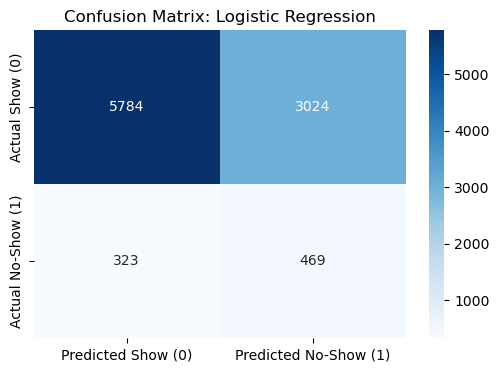

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_features = [
    'no_show_rate', 'previous_no_shows', 'previous_appointments', 
    'waiting_days', 'distance_km', 'age', 'children_count', 'income_ordinal',
    'has_chronic_disease', 'hypertension', 'diabetes', 'alcoholism', 'disability'
]

X = df[model_features]
y = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Show (0)', 'Predicted No-Show (1)'],
            yticklabels=['Actual Show (0)', 'Actual No-Show (1)'])
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

The initial Logistic Regression model struggles significantly, primarily due to a severe class imbalance in the dataset (~92% Class 0 vs. ~8% Class 1). 

**Key Insights**
* **The Accuracy Paradox:** The model achieves an overall accuracy of **65%**. However, because Class 0 makes up nearly 92% of the data, a baseline "dummy" model that only predicts the majority class would achieve ~91.7% accuracy. The current model is underperforming this baseline.
* **Minority Class (Class 1) Performance:** While the model manages to identify 59% of the actual positive cases (Recall: 0.59), it suffers from a remarkably high false positive rate. Precision for Class 1 is only **0.13**, resulting in a poor F1-Score of **0.22**. 

In [4]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
model = DecisionTreeClassifier(class_weight='balanced',max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.6933333333333334


In [5]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81      8808
           1       0.14      0.53      0.22       792

    accuracy                           0.69      9600
   macro avg       0.54      0.62      0.52      9600
weighted avg       0.88      0.69      0.76      9600



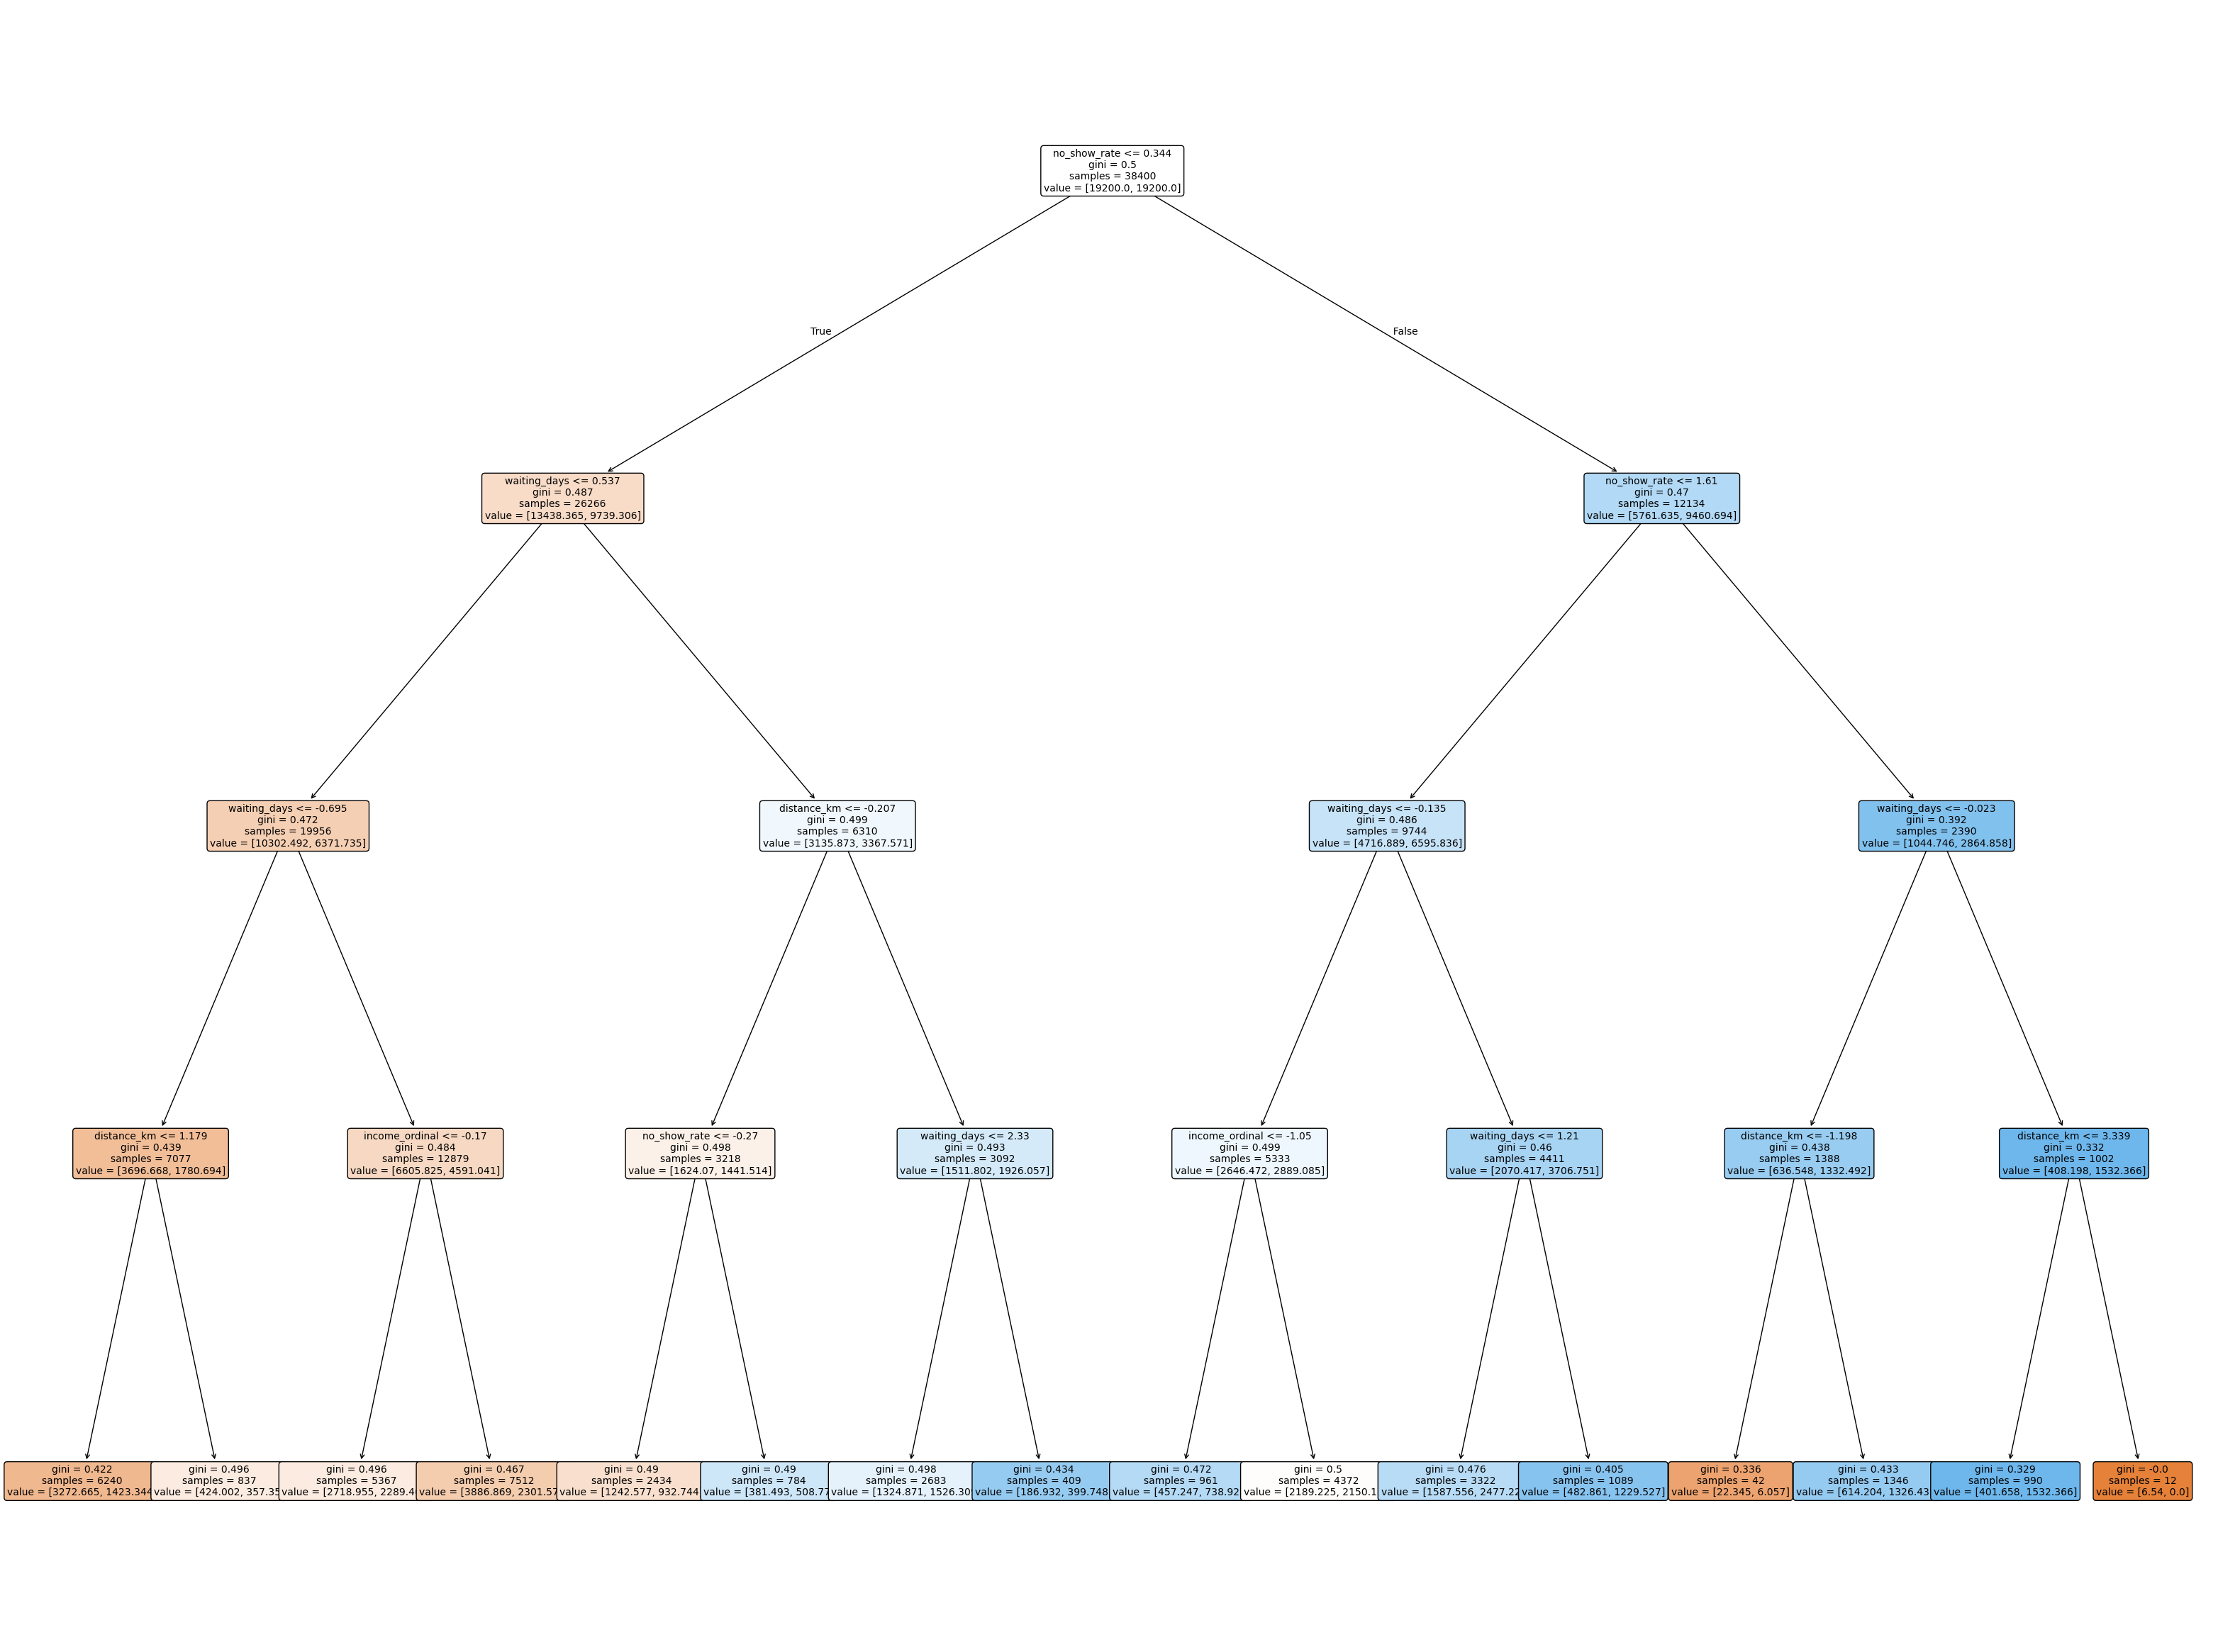

In [6]:
plt.figure(figsize=(40,30))
plot_tree(model,feature_names=X.columns,filled=True)
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

* **Primary Predictor:** The root node reveals that a patient's historical `no_show_rate` is the most significant initial factor determining whether they will attend their appointment.
* **Secondary Variables:** As the tree branches downward, it incorporates other behavioral and demographic features to refine the predictions, specifically evaluating `waiting_days`, `distance_km`, and `income_ordinal`.
* **Statistical Splitting:** Each box (node) details the mathematical partitioning of the data, displaying metrics like Gini impurity, total samples evaluated at that step, and value distributions.
* **Classification Outcomes:** The color-coded terminal leaves at the bottom represent the final groupings, visually separating the paths that lead to a high likelihood of a "show" versus a "no-show."